## Chosen standard models:
- Decision Tree (DecisionTreeClassifier)
- Logistic Regression (LogisticRegression)
- SVM (SVC)
- KNN (KNeighborsClassifier)
- Naive Bayes (GaussianNB)
## Chosen Ensemble models:
- Random Forest (Bagging) (RandomForestClassifier)
- Gradient Boosting (GradientBoostingClassifier)
- Stacking (StackingClassifier)

In [10]:
from src.preprocessor import DataPreprocessor
import pandas as pd
import yaml

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

path_input  = '../data/raw/ortodoncja.csv'
path_output = '../data/processed/'
path_config = '../config/preprocessor.yaml'

df = pd.read_csv(path_input)
with open(path_config, 'r') as f:
    config = yaml.safe_load(f)

### Example
p = DataPreprocessor(df, config)
p.preprocess()

model = RandomForestClassifier(random_state=config.get("random_state"))
model.fit(p.X_train, p.y_train)
s = model.score(p.X_test, p.y_test)
print(s)
print(model.classes_)

0.7222222222222222
[0 1 2]


## Evaluation metrics used:
- accuracy
- precision
- recall
- fall-out
- miss-rate
- selectivity
- f1-score
- roc-auc
- confusion matrix
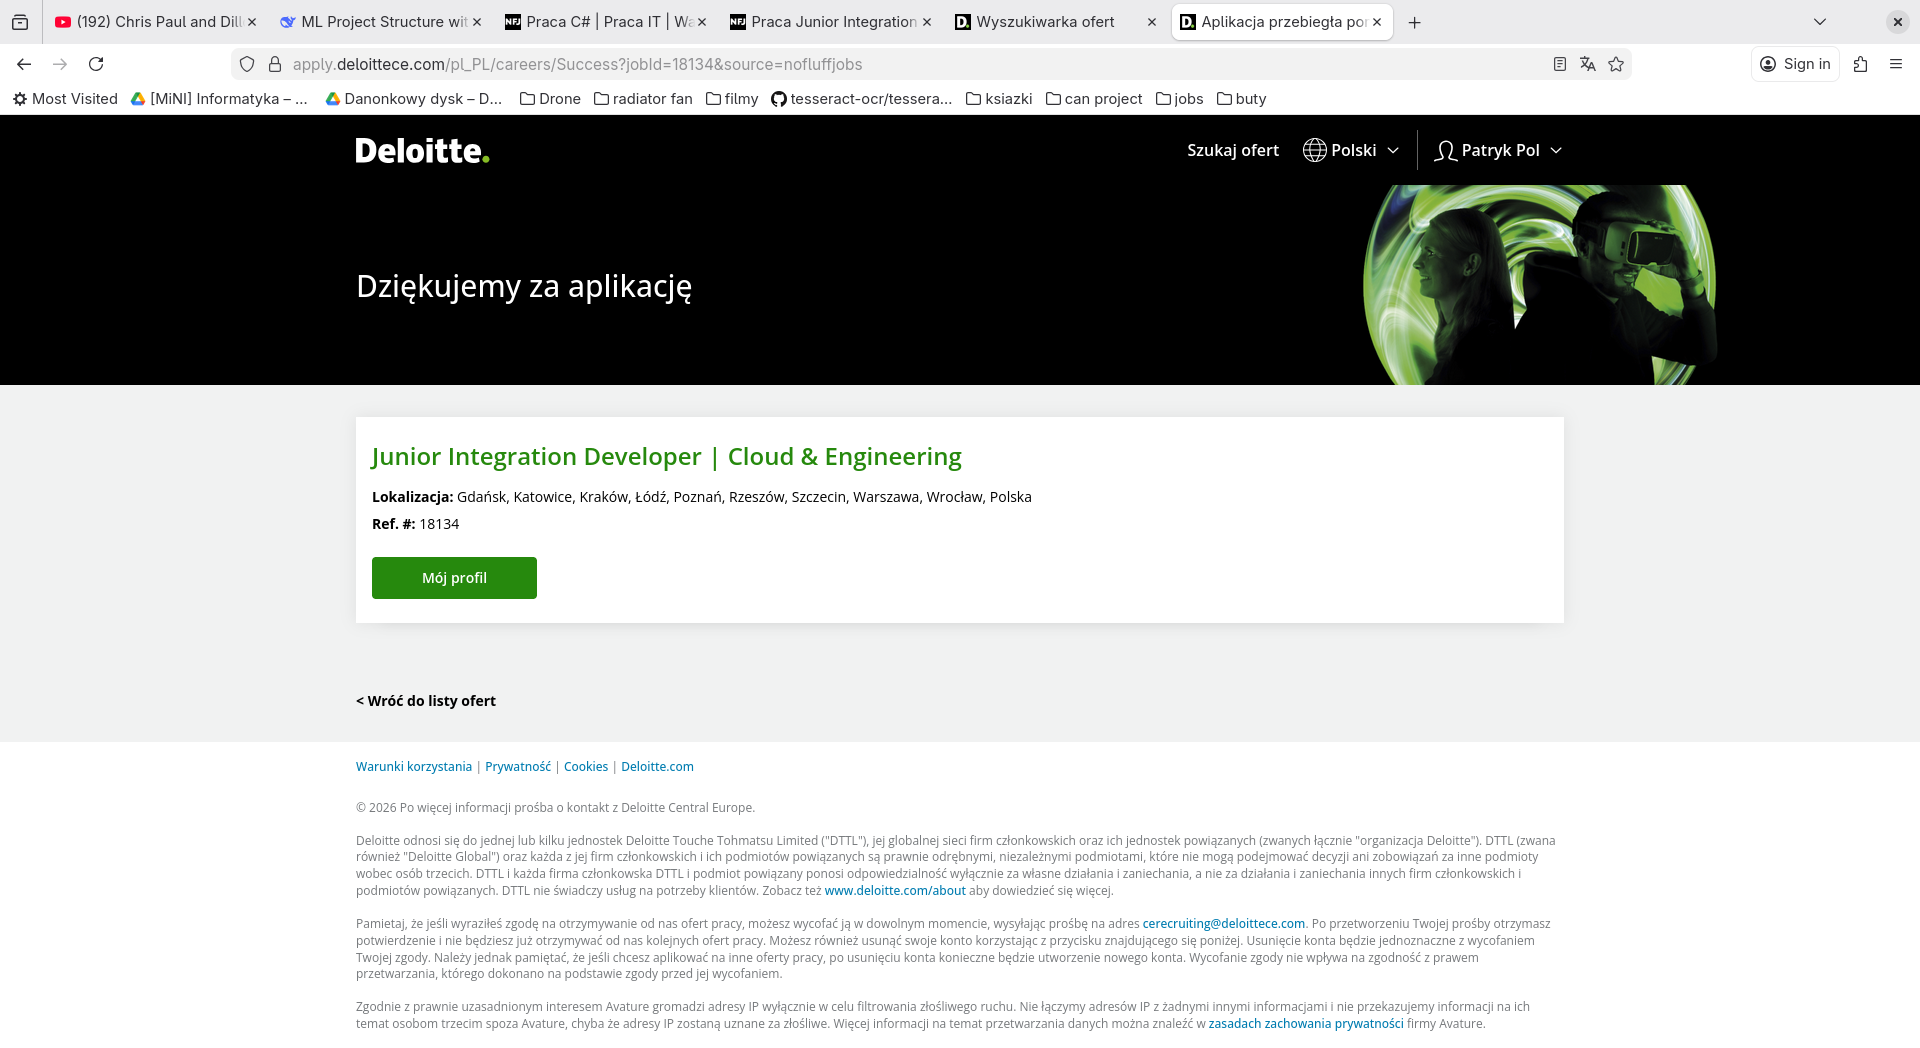

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

score = accuracy_score(p.y_test, model.predict(p.X_test))
f1 = f1_score(p.y_test, model.predict(p.X_test), average='weighted')
print(score)
print(f1)

0.7222222222222222
0.7041450547501884


## Cross-validation and hiper-parameter tuning:
- None
- 5-fold cross-validation
- Grid Search with cross-validation

In [19]:
from sklearn.model_selection import cross_val_score, GridSearchCV

cv_s = cross_val_score(
    model, p.X_train, p.y_train, cv=5, scoring='accuracy'
)

print(cv_s.mean())

0.8089593114241002
